# Ch 7-8 Homework


In [1]:
from helper_functions import *

# Question 9 in Section 7.9

This question uses the variables dis (the weighted mean of distances
to five Boston employment centers) and nox (nitrogen oxides concentration in parts per 10 million) from the Boston data. We will treat
dis as the predictor and nox as the response.

a) Use the poly() function from the ISLP.models module to fit a
cubic polynomial regression to predict nox using dis. Report the
regression output, and plot the resulting data and polynomial
fits.

In [2]:
boston_df = pd.read_csv('../Data/Boston.csv', index_col=0)
boston_df = boston_df.dropna()

In [13]:
X = boston_df[predictor]

In [ ]:
predictor = ['dis']
response  = ['nox']

X_dis = boston_df[predictor]
y = boston_df[response]

X3 = MS([poly('dis ', degree = 3)``]).fit_transform(X_dis)
X3

ValueError: expecting either a column or a Feature

In [6]:
poly?

Signature: poly(col, degree=1, intercept=False, raw=False, name=None)
Docstring:
Create a polynomial Feature
for a given column.

Additional `args` and `kwargs`
are passed to `Poly`.

Parameters
----------

col : column identifier or Column
    Column to transform.

degree : int, default=1
    Degree of polynomial.

intercept : bool, default=False
    Include a column for intercept?

raw : bool, default=False
    If False, perform a QR decomposition on the resulting
    matrix of powers of centered and / or scaled features.

name : str (optional)
    Defaults to one derived from col.

Returns
-------

var : Feature
File:      ~/anaconda3/envs/islp/lib/python3.12/site-packages/ISLP/models/model_spec.py
Type:      function

b) Plot the polynomial fits for a range of different polynomial
degrees (say, from 1 to 10), and report the associated residual
sum of squares.

c) Perform cross-validation or another approach to select the opti-
mal degree for the polynomial, and explain your results.

d) Use the bs() function from the ISLP.models module to fit a re-
gression spline to predict nox using dis. Report the output for
the fit using four degrees of freedom. How did you choose the
knots? Plot the resulting fit.

e) Now fit a regression spline for a range of degrees of freedom, and
plot the resulting fits and report the resulting RSS. Describe the
results obtained.

f) Perform cross-validation or another approach in order to select
the best degrees of freedom for a regression spline on this data.
Describe your results.

Question 10 in Section 7.9

This question relates to the College data set.

a) Split the data into a training set and a test set. Using out-of-state
tuition as the response and the other variables as the predictors,
perform forward stepwise selection on the training set in order
to identify a satisfactory model that uses just a subset of the
predictors.

b) Fit a GAM on the training data, using out-of-state tuition as
the response and the features selected in the previous step as
the predictors. Plot the results, and explain your findings.

c) Evaluate the model obtained on the test set, and explain the
results obtained.

d) For which variables, if any, is there evidence of a non-linear
relationship with the response?

Question 8 in Section 8.4

In the lab, a classification tree was applied to the Carseats data set af-
ter converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

a) Split the data set into a training set and a test set.

b) Fit a regression tree to the training set. Plot the tree, and inter-
pret the results. What test MSE do you obtain?

c) Use cross-validation in order to determine the optimal level of
tree complexity. Does pruning the tree improve the test MSE?

d) Use the bagging approach in order to analyze this data. What
test MSE do you obtain? Use the feature_importance_ values to
determine which variables are most important.

e) Use random forests to analyze this data. What test MSE do
you obtain? Use the feature_importance_ values to determine
which variables are most important. Describe the effect of m, the
number of variables considered at each split, on the error rate
obtained.

f) Now analyze the data using BART, and report your results.

Question 9 in Section 8.4

This problem involves the OJ data set which is part of the ISLP
package.

a) Create a training set containing a random sample of 800 obser-
vations, and a test set containing the remaining observations.

b) Fit a tree to the training data, with Purchase as the response
and the other variables as predictors. What is the training error
rate?

c) Create a plot of the tree, and interpret the results. How many
terminal nodes does the tree have?

d) Use the export_tree() function to produce a text summary of
the fitted tree. Pick one of the terminal nodes, and interpret the
information displayed.

e) Predict the response on the test data, and produce a confusion
matrix comparing the test labels to the predicted test labels.
What is the test error rate?

f) Use cross-validation on the training set in order to determine
the optimal tree size.

g) Produce a plot with tree size on the x-axis and cross-validated
classification error rate on the y-axis.

h) Which tree size corresponds to the lowest cross-validated classi-
fication error rate?

i) Produce a pruned tree corresponding to the optimal tree size
obtained using cross-validation. If cross-validation does not lead
to selection of a pruned tree, then create a pruned tree with five
terminal nodes.

j) Compare the training error rates between the pruned and un-
pruned trees. Which is higher?

k) Compare the test error rates between the pruned and unpruned
trees. Which is higher?

Question 10 in Section 8.4

We now use boosting to predict Salary in the Hitters data set.

In [23]:
 from sklearn.tree import ( DecisionTreeClassifier as DTC ,
                            DecisionTreeRegressor as DTR ,
                            plot_tree ,
                            export_text )
from sklearn.metrics import (accuracy_score ,
                                log_loss )
from sklearn. ensemble import \
                                ( RandomForestRegressor as RF ,
                                GradientBoostingRegressor as GBR)
from ISLP.bart import BART

In [ ]:
#loading in the Data
hitters_df = pd.read_csv('../Homework_Data/Hitters.csv')

a) Remove the observations for whom the salary information is
unknown, and then log-transform the salaries.

In [38]:
#getting rid of the missing values from the DataFrame
hitters_df = hitters_df.dropna()

#applying the log transform to the salaries column
hitters_df['log_Salary'] = np.log10(hitters_df['Salary'])

b) Create a training set consisting of the first 200 observations, and
a test set consisting of the remaining observations.

In [39]:
training_df, testing_df = hitters_df.iloc[:200], hitters_df.iloc[200:]

c) Perform boosting on the training set with 1,000 trees for a range
of values of the shrinkage parameter λ. Produce a plot with
different shrinkage values on the x-axis and the corresponding
training set MSE on the y-axis.

In [107]:
#this code converts the categorical variables into dummy variables
training_df = pd.get_dummies(training_df)
#we drop the salaray column from the training DataFrame
#training_df.drop(columns = ['Salary'], inplace = True)

#we then split into X and y training sets
X_train = training_df.drop(columns = ['log_Salary'])
y_train = training_df['log_Salary']

In [ ]:
#we do the same for the testing DataFrame
#converting the categorical variables into dummy variables
testing_df = pd.get_dummies(testing_df)
testing_df.drop(columns = ['Salary'], inplace = True)

#we split into X and y testing sets
X_test = testing_df.drop(columns = ['log_Salary'])
y_test = testing_df['log_Salary']

In [44]:
def mse(y_obs, y_model):
    """
    Compute the Mean Squared Error (MSE) between observed and model values.

    Parameters:
    -----------
    y_obs : array-like
        Observed data points.
    y_model : array-like
        Model-predicted values.

    Returns:
    --------
    float
        The mean squared error.
    """
    residuals = y_obs - y_model
    return np.mean(residuals**2)

In [119]:
boost_hitters = GBR(n_estimators =1000 ,
                        learning_rate = 10,
                        max_depth =3,
                        random_state =2322)
                        
boost_hitters.fit(X_train , y_train)
models.append(boost_hitters)

/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:261: RuntimeWarning: invalid value encountered in add
  raw_prediction[:, k] += learning_rate * tree.value[:, 0, 0].take(


In [120]:
mse_lambdas = []
models = []

lambdas = np.array([0.0001, 0.001, 0.01, 0.1, 1])
for l in lambdas:
    boost_hitters = GBR(n_estimators =1000 ,
                        learning_rate = l,
                        max_depth =3,
                        random_state =2322)
                        
    boost_hitters.fit(X_train , y_train)
    models.append(boost_hitters)


    y_hat_boost = boost_hitters.predict(X_train)
    mse_lambdas.append(mse(y_train , y_hat_boost))


d) Produce a plot with different shrinkage values on the x-axis and
the corresponding test set MSE on the y-axis.

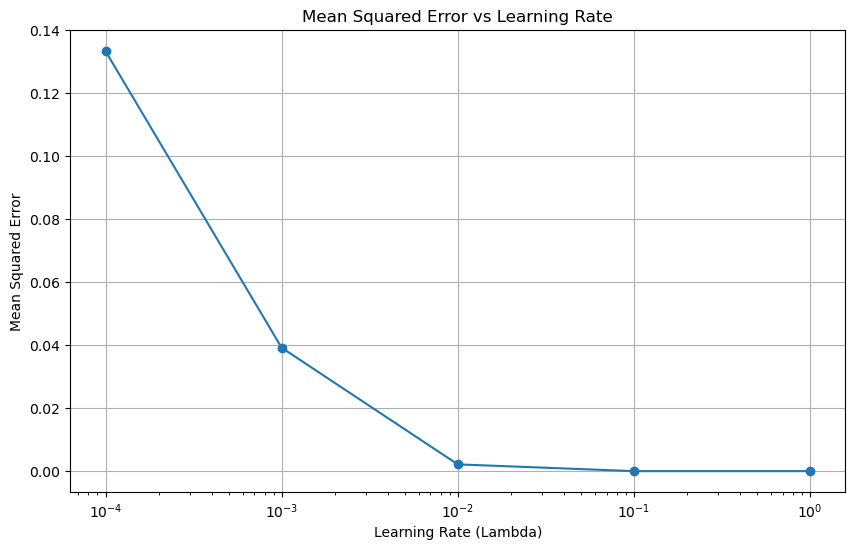

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lambdas, mse_lambdas, marker='o')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (Lambda)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Mean Squared Error vs Learning Rate')
ax.grid(True)
plt.show()

e) Compare the test MSE of boosting to the test MSE that results
from applying two of the regression approaches seen in
Chapters 3 and 6.

In [50]:
training_df.columns.values

array(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years',
       'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts',
       'Assists', 'Errors', 'log_Salary', 'League_A', 'League_N',
       'Division_E', 'Division_W', 'NewLeague_A', 'NewLeague_N'],
      dtype=object)

In [53]:
################### 
# This is working on the multiple linear regression model
###################
design = MS(training_df.columns.values)
X_train = design.fit_transform(training_df)

hitter_regression = sm.OLS(y_train, X_train)
hitter_results = hitter_regression.fit()
summarize(hitter_results)

,coef,std err,t,P>|t|
intercept,-1.110000e-16,2.570000e-15,-4.300000e-02,0.966
AtBat,-4.510000e-17,2.690000e-17,-1.679000e+00,0.095
Hits,9.714000e-17,9.600000e-17,1.012000e+00,0.313
HmRun,-2.567000e-16,2.290000e-16,-1.120000e+00,0.264
Runs,-3.469000e-17,1.150000e-16,-3.030000e-01,0.762
RBI,1.665000e-16,9.670000e-17,1.722000e+00,0.087
Walks,-7.633000e-17,6.940000e-17,-1.100000e+00,0.273
Years,-3.886000e-16,4.520000e-16,-8.600000e-01,0.391
CAtBat,5.421000e-18,4.860000e-18,1.115000e+00,0.267
CHits,-9.216000e-18,2.430000e-17,-3.780000e-01,0.706


In [54]:
yhat_linreg = hitter_results.predict(X_train)

mse(y_train, yhat_linreg)

np.float64(9.265368547047089e-29)

In [69]:
# performing forward step selection of features

import numpy as np
import pandas as pd
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


def forward_stepwise_selection(X, Y):
    
    selected_features = []
    remaining_features = list(X.columns)
    best_models = []
    
    for k in range(1, len(X.columns) + 1):
        best_mse = np.inf
        best_feature = None
        best_model = None
        
        for feature in remaining_features:
            # Try adding one feature at a time
            features_to_try = selected_features + [feature]
            X_subset = X[features_to_try]
            
            model = LinearRegression().fit(X_subset, Y)
            y_pred = model.predict(X_subset)
            #model = sm.OLS(Y, X_subset).fit()
            mse = mean_squared_error(Y, y_pred)
            
            if mse < best_mse:
                best_mse = mse
                best_feature = feature
                best_model = model
        
        # Add the best feature and update lists
        if best_feature:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            best_models.append((list(selected_features), best_mse, best_model))
    
    return best_models

# Run forward stepwise selection
best_models_fs = forward_stepwise_selection(X_train, y_train)

# Extract number of features and training MSEs
num_features_fs = list(range(1, len(X_train.columns) + 1))
train_mse_fs = [mse for _, mse, _ in best_models_fs]

In [72]:
np.argmin(train_mse_fs)

np.int64(18)

In [73]:
best_models_fs[18]

(['CRBI',
  'Hits',
  'Years',
  'PutOuts',
  'Division_E',
  'Walks',
  'AtBat',
  'Assists',
  'CWalks',
  'CRuns',
  'CHmRun',
  'League_A',
  'Errors',
  'CHits',
  'CAtBat',
  'HmRun',
  'RBI',
  'Runs',
  'NewLeague_A'],
 0.060426164479318825,
 LinearRegression())

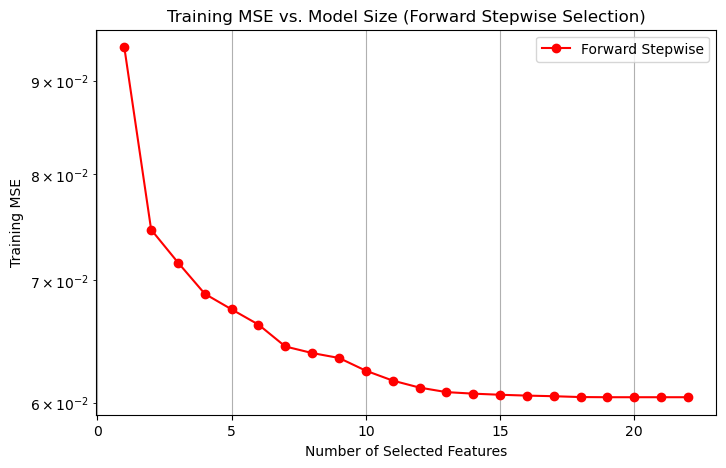

In [70]:
# Plot training MSE vs. number of features
plt.figure(figsize=(8, 5))
plt.plot(num_features_fs, train_mse_fs, marker='o', linestyle='-', color='r', label="Forward Stepwise")
plt.xlabel("Number of Selected Features")
plt.ylabel("Training MSE")
plt.title("Training MSE vs. Model Size (Forward Stepwise Selection)")
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import \
                                    (cross_validate ,
                                    KFold ,
                                    ShuffleSplit )

from sklearn.model_selection import GridSearchCV

lambdas = 10**np.linspace(8, -2, 100)/y_train.std().values

#Ridge Method

ridge = Ridge(fit_intercept = True)
scaler = StandardScaler(with_mean =True , with_std =True)
pipe = Pipeline (steps =[( 'scaler', scaler), ('ridge', ridge)])

#using validation method
validation = ShuffleSplit(n_splits =1,
                              test_size = 0.2 ,
                              random_state = 324234)

param_grid = {'ridge__alpha': lambdas}

grid = GridSearchCV ( pipe ,
                          param_grid ,
                          scoring='neg_mean_squared_error', 
                          cv=validation)

grid.fit(X_train, y_train)
best_lambda = grid.best_params_['ridge__alpha']
best_ridge_model = grid.best_estimator_

In [82]:
#checking the coefficients of the ridge fitting
best_ridge_model.named_steps['ridge'].coef_

array([ 0.00299258,  0.07051954,  0.00256355,  0.03662893,  0.00958208,
        0.03581334,  0.07040551,  0.02812526,  0.03517431,  0.02390769,
        0.03291979,  0.02955593, -0.01375786,  0.0451817 ,  0.02781512,
       -0.02253726, -0.01186889,  0.01186889,  0.01752667, -0.01752667,
        0.00079964, -0.00079964])

In [95]:
for cols, beta in zip(X_train.columns, best_ridge_model.named_steps['ridge'].coef_):
    print(f"{cols:14}: {beta:7.4f}")

AtBat         :  0.0030
Hits          :  0.0705
HmRun         :  0.0026
Runs          :  0.0366
RBI           :  0.0096
Walks         :  0.0358
Years         :  0.0704
CAtBat        :  0.0281
CHits         :  0.0352
CHmRun        :  0.0239
CRuns         :  0.0329
CRBI          :  0.0296
CWalks        : -0.0138
PutOuts       :  0.0452
Assists       :  0.0278
Errors        : -0.0225
League_A      : -0.0119
League_N      :  0.0119
Division_E    :  0.0175
Division_W    : -0.0175
NewLeague_A   :  0.0008
NewLeague_N   : -0.0008


Text(0, 0.5, 'Cross - validated MSE ')

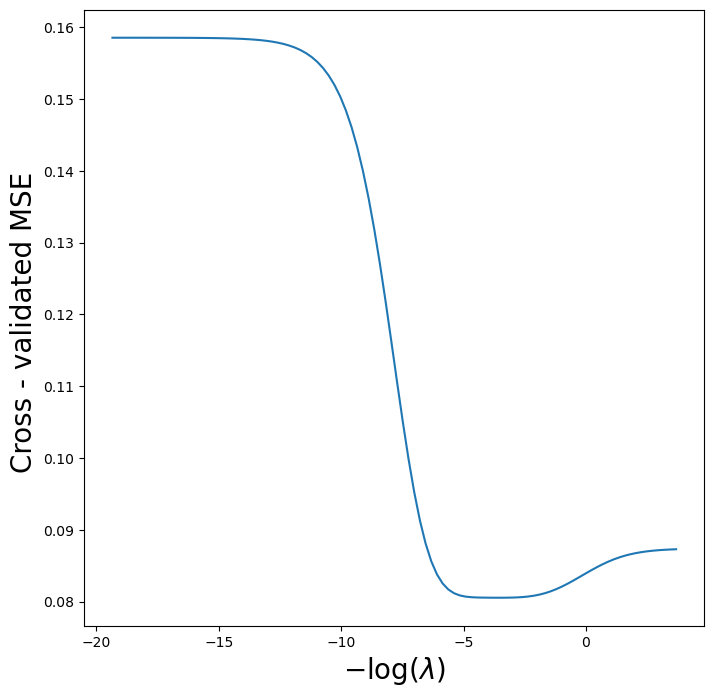

In [84]:
ridge_fig , ax = plt.subplots (figsize =(8 ,8))
ax.errorbar (-np.log(lambdas),
-grid.cv_results_['mean_test_score'],
yerr=grid.cv_results_ ['std_test_score'])
ax. set_xlabel (r'$-\log (\lambda)$', fontsize =20)
ax. set_ylabel ('Cross - validated MSE ', fontsize =20)

In [100]:
y_train.std().values

array([0.39713467])

In [101]:
from sklearn.linear_model import Lasso

#Lasso Method

lambdas = 10**np.linspace(8, -7, 100)/y_train.std().values

lassoCV = Lasso(fit_intercept = True)
scaler = StandardScaler(with_mean =True , with_std =True)

pipeCV = Pipeline (steps =[( 'scaler', scaler), ('lasso', lassoCV)])

param_grid_lasso = {'lasso__alpha': lambdas}
validation = ShuffleSplit (n_splits =1,
                                test_size = 0.2 ,
                                random_state =0)
grid = GridSearchCV ( pipeCV,
                          param_grid_lasso ,
                          scoring='neg_mean_squared_error', 
                          cv=validation)

grid.fit(X_train, y_train)
best_alpha = grid.best_params_['lasso__alpha']
best_lasso_model = grid.best_estimator_

/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.927e-02, tolerance: 2.404e-03
  model = cd_fast.enet_coordinate_descent(
/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.902e-02, tolerance: 2.404e-03
  model = cd_fast.enet_coordinate_descent(
/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

In [102]:
for cols, beta in zip(X_train.columns, best_lasso_model.named_steps['lasso'].coef_):
    print(f"{cols:14}: {beta:7.4f}")

AtBat         : -0.1326
Hits          :  0.2223
HmRun         :  0.0045
Runs          :  0.0119
RBI           : -0.0000
Walks         :  0.0669
Years         :  0.1293
CAtBat        :  0.0000
CHits         :  0.0000
CHmRun        :  0.0477
CRuns         :  0.1054
CRBI          :  0.0000
CWalks        : -0.0739
PutOuts       :  0.0533
Assists       :  0.0379
Errors        : -0.0232
League_A      : -0.0232
League_N      :  0.0000
Division_E    :  0.0312
Division_W    : -0.0000
NewLeague_A   :  0.0000
NewLeague_N   : -0.0000


Text(0, 0.5, 'Cross - validated MSE ')

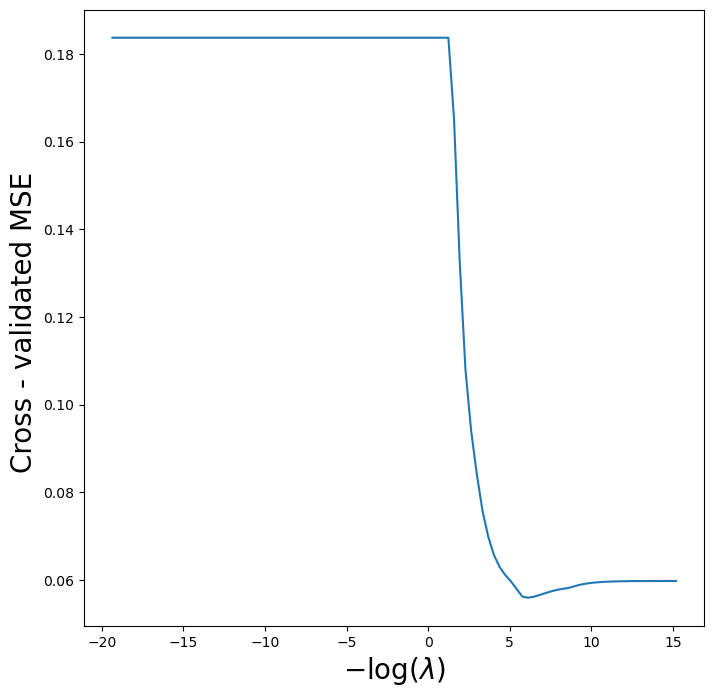

In [103]:
lasso_fig , ax = plt.subplots (figsize =(8 ,8))

ax.errorbar (-np.log(lambdas),
-grid.cv_results_['mean_test_score'],
yerr=grid.cv_results_ ['std_test_score'])
ax. set_xlabel (r'$-\log (\lambda)$', fontsize =20)
ax. set_ylabel ('Cross - validated MSE ', fontsize =20)

f) Which variables appear to be the most important predictors in
the boosted model?

In [113]:
features_importance = [mod.feature_importances_ for mod in models]

In [126]:
for col, imp in zip(X_train.columns,features_importance[np.argmin(mse_lambdas)]):
    print(f'{col:13}: {imp:.2f}')


AtBat        : 0.00
Hits         : 0.03
HmRun        : 0.01
Runs         : 0.00
RBI          : 0.07
Walks        : 0.08
Years        : 0.02
CAtBat       : 0.61
CHits        : 0.02
CHmRun       : 0.01
CRuns        : 0.06
CRBI         : 0.02
CWalks       : 0.01
PutOuts      : 0.02
Assists      : 0.01
Errors       : 0.02
League_A     : 0.00
League_N     : 0.00
Division_E   : 0.00
Division_W   : 0.00
NewLeague_A  : 0.00
NewLeague_N  : 0.00


g) Now apply bagging to the training set. What is the test set MSE
for this approach?

In [ ]:
bag_hitter = RF( max_features =X_train.shape[1], random_state =0)
bag_hitter fit(X_train , y_train)

RandomForestRegressor(max_features=22, random_state=0)

In [ ]:
#Calculating the MSE for the Bagging Approach
y_at_bag = bag_hitter.predict(X_test)
mse(y_test, y_hat_bag)

np.float64(0.04487375984658633)

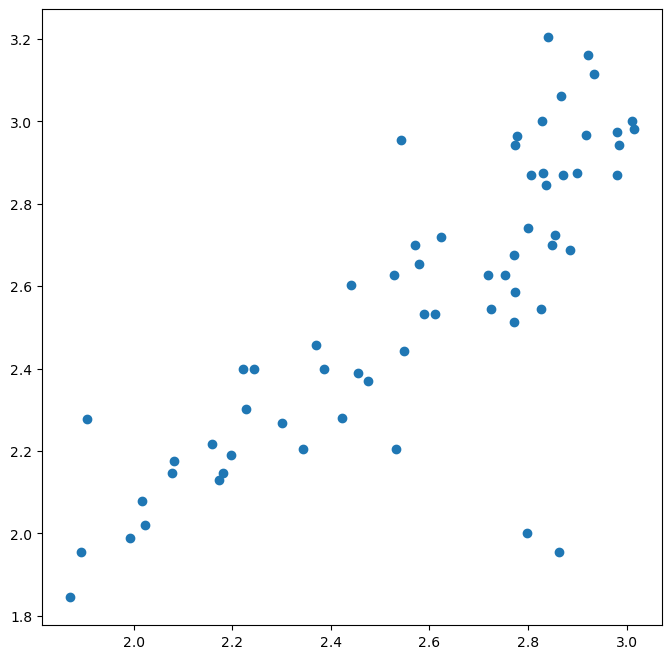

np.float64(0.04487375984658633)

In [129]:
ax = plt.subplots (figsize =(8 ,8))[1]
y_hat_bag = bag_hitter.predict(X_test)
ax.scatter(y_hat_bag , y_test)
plt.show()
np.mean (( y_test - y_hat_bag )**2)

In [133]:
feature_names =  X_train.columns
feature_imp = pd. DataFrame (
{'importance ': bag_hitter.feature_importances_ },
index= feature_names )
feature_imp.sort_values (by='importance ', ascending =False)

,importance
CAtBat,0.539946
CHits,0.075483
CRuns,0.061711
AtBat,0.053025
Walks,0.047263
CRBI,0.044587
CWalks,0.031757
CHmRun,0.030344
RBI,0.021544
Hits,0.021463
